# Binary Treatment Causal Analysis


In [43]:
import warnings
import re
import sys
from pathlib import Path

import graphviz
import numpy as np
import pandas as pd
from dowhy import CausalModel
from IPython.display import display
from sklearn.exceptions import DataConversionWarning
from sklearn.preprocessing import RobustScaler

warnings.filterwarnings("ignore", category=DataConversionWarning)


def find_repo_root(start=Path.cwd()):
    for candidate in [start, *start.parents]:
        if (candidate / "utils" / "statistical_tests.py").exists():
            return candidate
    raise RuntimeError("Could not find repo root containing utils/statistical_tests.py")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from utils import statistical_tests as tests


In [44]:
INPUT_FILE = "alerts_with_lib_category_and_apk_size_cryptoguard.csv"


def normalize_verdict(value):
    normalized = str(value).strip().lower()
    if normalized in {"1", "true"}:
        return 1
    if normalized in {"0", "false"}:
        return 0
    raise ValueError(f"Unsupported verdict value: {value!r}")


def normalize_rule_id(value):
    if pd.isna(value):
        return "missing"
    value = str(value).strip()
    if not value:
        return "missing"
    return re.sub(r"[^0-9A-Za-z_]+", "_", value)


def add_rule_id_confounders(data):
    rule_id_dummies = pd.get_dummies(data["rule_id"], prefix="rule_id", drop_first=True, dtype=int)
    return pd.concat([data, rule_id_dummies], axis=1), list(rule_id_dummies.columns)


df = pd.read_csv(INPUT_FILE)
print("Original rows:", len(df))

df = df[~df["code_location"].str.contains("obfuscated", case=False, na=False)].copy()
print("After removing obfuscated:", len(df))

df["verdict"] = df["verdict"].apply(normalize_verdict)
df["is_third_party"] = (~df["code_location"].isin(["developer_written"])).astype(int)
df["lib_category"] = df["code_location"].apply(lambda x: x if x != "developer_written" else "source")

rule_id_source_column = "rule_id" if "rule_id" in df.columns else "ruleId"
df["rule_id"] = df[rule_id_source_column].apply(normalize_rule_id)

print("\nis_third_party counts:")
print(df["is_third_party"].value_counts())

# Combined treatment: 1 means all classified alerts are reported; 0 means developer-written-only alerts are reported.
df_all = df.copy()
df_all["combined"] = 1
df_developer_written = df[df["code_location"] == "developer_written"].copy()
df_developer_written["combined"] = 0
df = pd.concat([df_all, df_developer_written], ignore_index=True)

print("\nVerdict value counts:")
print(df["verdict"].value_counts())
print("\nCode location value counts:")
print(df["code_location"].value_counts())
print("\nTop rule_id counts:")
print(df["rule_id"].value_counts().head(20))


Original rows: 15272
After removing obfuscated: 15272

is_third_party counts:
is_third_party
1    13954
0     1318
Name: count, dtype: int64

Verdict value counts:
verdict
0    8557
1    8033
Name: count, dtype: int64

Code location value counts:
code_location
Android              6678
others               4044
Utilities            2681
developer_written    2636
SocialMedia           463
Cloud                  51
Analytics              37
Name: count, dtype: int64

Top rule_id counts:
rule_id
13    6910
2     5658
7     1256
3     1141
10     855
1      398
8      126
9      121
14      54
11      49
12      17
4        5
Name: count, dtype: int64


In [45]:
scaler = RobustScaler()
df["apk_size_scaled"] = scaler.fit_transform(df[["apk_size"]])

category_order = [
    "<100",
    "100-500",
    "500-1k",
    "1k-5k",
    "5k-10k",
    "10k-50k",
    "50k-100k",
    "100k-500k",
    "500k-1M",
    "1M-5M",
    ">5M",
]

popularity_column = "app_popularity" if "app_popularity" in df.columns else "apk_category"
df["app_popularity_encoded"] = pd.Categorical(
    df[popularity_column],
    categories=category_order,
    ordered=True,
).codes

df, rule_id = add_rule_id_confounders(df)
common_causes = ["is_third_party", "apk_size_scaled", "app_popularity_encoded", *rule_id]

print("Rule ID confounder columns:", len(rule_id))
print(rule_id[:20])


Rule ID confounder columns: 11
['rule_id_10', 'rule_id_11', 'rule_id_12', 'rule_id_13', 'rule_id_14', 'rule_id_2', 'rule_id_3', 'rule_id_4', 'rule_id_7', 'rule_id_8', 'rule_id_9']


In [46]:
def all_correlation_tests():
    tests.kruskal_test_continuous_by_groups(df, "app_popularity_encoded", "apk_size_scaled")

    tests.logistic_regression_numeric_to_binary(df, "app_popularity_encoded", "verdict")
    tests.chi_square_test_cat_to_binary(df, "app_popularity_encoded", "verdict")
    tests.logistic_regression_numeric_to_binary(df, "app_popularity_encoded", "combined")
    tests.chi_square_test_cat_to_binary(df, "app_popularity_encoded", "combined")

    tests.logistic_regression_numeric_to_binary(df, "apk_size_scaled", "verdict")
    tests.mann_whitney_test(df, "apk_size_scaled", "verdict")
    tests.logistic_regression_numeric_to_binary(df, "apk_size_scaled", "combined")
    tests.mann_whitney_test(df, "apk_size_scaled", "combined")

    tests.logistic_regression_binary_to_binary(df, "is_third_party", "verdict")
    tests.chi_square_test_cat_to_binary(df, "is_third_party", "verdict")

    tests.chi_square_test_cat_to_binary(df, "rule_id", "verdict")
    tests.chi_square_test_cat_to_binary(df, "rule_id", "combined")

    tests.logistic_regression_binary_to_binary(df, "combined", "verdict")
    tests.correlation_test_treatment_to_outcome(df)


all_correlation_tests()



app_popularity_encoded -> apk_size_scaled (Kruskal-Wallis)
H = 1220.766, p = 0.0000
Edge is not rejected (p < 0.05)

app_popularity_encoded -> verdict (Logistic regression)
coef = 0.0364, p = 0.0000
Edge is not rejected (p < 0.05)

app_popularity_encoded -> verdict (Chi-square)
chi2 = 176.312, dof = 10, p = 0.0000
Edge is not rejected (p < 0.05)

app_popularity_encoded -> combined (Logistic regression)
coef = 0.0339, p = 0.0001
Edge is not rejected (p < 0.05)

app_popularity_encoded -> combined (Chi-square)
chi2 = 245.379, dof = 10, p = 0.0000
Edge is not rejected (p < 0.05)

apk_size_scaled -> verdict (Logistic regression)
coef = -0.0613, p = 0.0000
Edge is not rejected (p < 0.05)

apk_size_scaled -> verdict (Mann-Whitney U)
U = 37898481.000, p = 0.0000
Edge is not rejected (p < 0.05)

apk_size_scaled -> combined (Logistic regression)
coef = 0.1472, p = 0.0000
Edge is not rejected (p < 0.05)

apk_size_scaled -> combined (Mann-Whitney U)
U = 8673884.500, p = 0.0000
Edge is not rejecte

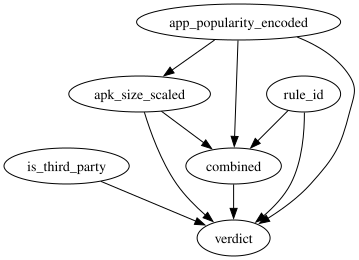


------- Identified estimand -------
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                                                         ↪
───────────(E[verdict|is_third_party,rule_id_10,rule_id_12,rule_id_11,rule_id_ ↪
d[combined]                                                                    ↪

↪                                                                              ↪
↪ 9,rule_id_14,app_popularity_encoded,rule_id_7,rule_id_3,rule_id_13,rule_id_4 ↪
↪                                                                              ↪

↪                                       
↪ ,rule_id_8,rule_id_2,apk_size_scaled])
↪                                       
Estimand assumption 1, Unconfoundedness: If U→{combined} and U→verdict then P(verdict|combined,is_third_party,rule_id_10,rule_id_12,rule_id_11,rule_id_9,rule_id_14,app_popularity_encoded,rule_id_7,rule_id_3,rule_id_13,rule_id_4,rule_id_8,rule_

In [47]:
rule_id_edges = "\n".join(
    f"    {column} -> combined;\n    {column} -> verdict;" for column in rule_id
)

# Display a readable graph with rule_id as one categorical confounder.
display_graph = """
digraph {
    combined -> verdict;
    is_third_party -> verdict;
    apk_size_scaled -> combined;
    apk_size_scaled -> verdict;
    app_popularity_encoded -> combined;
    app_popularity_encoded -> verdict;
    app_popularity_encoded -> apk_size_scaled;
    rule_id -> combined;
    rule_id -> verdict;
}
"""

# DoWhy still needs the one-hot rule_id columns for estimation.
model_graph = f"""
digraph {{
    combined -> verdict;
    is_third_party -> verdict;
    is_third_party -> combined;
    apk_size_scaled -> combined;
    apk_size_scaled -> verdict;
    app_popularity_encoded -> combined;
    app_popularity_encoded -> verdict;
    app_popularity_encoded -> apk_size_scaled;
{rule_id_edges}
}}
"""

display(graphviz.Source(display_graph))

model = CausalModel(
    data=df,
    treatment="combined",
    outcome="verdict",
    graph=model_graph.replace("\n", " "),
    common_causes=common_causes,
)

identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
print("\n------- Identified estimand -------")
print(identified_estimand)


In [48]:
estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.propensity_score_matching",
    target_units="ate",
    test_significance=True,
    confidence_intervals="bootstrap",
    method_params={
        "num_simulations": 300,
        "sample_size_fraction": 1.0,
        "confidence_level": 0.95,
    },
)

print("\n------- Causal effect estimate -------")
print(estimate)



------- Causal effect estimate -------
*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                                                         ↪
───────────(E[verdict|is_third_party,rule_id_10,rule_id_12,rule_id_11,rule_id_ ↪
d[combined]                                                                    ↪

↪                                                                              ↪
↪ 9,rule_id_14,app_popularity_encoded,rule_id_7,rule_id_3,rule_id_13,rule_id_4 ↪
↪                                                                              ↪

↪                                       
↪ ,rule_id_8,rule_id_2,apk_size_scaled])
↪                                       
Estimand assumption 1, Unconfoundedness: If U→{combined} and U→verdict then P(verdict|combined,is_third_party,rule_id_10,rule_id_12,rule_id_11,rule_id_9,rule_id_14,app_popularity_encoded,rule_

In [49]:
estimate.interpret(method_name="textual_effect_interpreter")

refutation_methods = [
    "random_common_cause",
    "placebo_treatment_refuter",
    "data_subset_refuter",
    "dummy_outcome_refuter",
]

for method in refutation_methods:
    if method == "placebo_treatment_refuter":
        ref = model.refute_estimate(
            identified_estimand,
            estimate,
            method_name=method,
            placebo_type="permute",
            num_simulations=200,
        )
    elif method == "data_subset_refuter":
        ref = model.refute_estimate(
            identified_estimand,
            estimate,
            method_name=method,
            subset_fraction=0.8,
            num_simulations=200,
        )
    elif method == "dummy_outcome_refuter":
        ref = model.refute_estimate(
            identified_estimand,
            estimate,
            method_name=method,
            num_simulations=200,
        )
    else:
        ref = model.refute_estimate(identified_estimand, estimate, method_name=method)

    print(f"\nRefuter: {method}\n", ref)


Increasing the treatment variable(s) [combined] from 0 to 1 causes an increase of -0.4391802290536468 in the expected value of the outcome [['verdict']], over the data distribution/population represented by the dataset.

Refuter: random_common_cause
 Refute: Add a random common cause
Estimated effect:-0.4391802290536468
New effect:-0.43918022905364673
p value:1.0


Refuter: placebo_treatment_refuter
 Refute: Use a Placebo Treatment
Estimated effect:-0.4391802290536468
New effect:0.0006461723930078361
p value:0.8999999999999999


Refuter: data_subset_refuter
 Refute: Use a subset of data
Estimated effect:-0.4391802290536468
New effect:-0.43812047920434
p value:0.6399999999999999


Refuter: dummy_outcome_refuter
